# Classifying movie reviews. A binary classification

This notebook contains code from the book Deep Learning with Python by Francois Chollet
Chapter 3.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# Set style for visualizations
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")

In this example, we will learn to classify movie reviews into "positive" reviews and "negative" reviews, just based on the text content of the reviews.

Test set has already been preprocessed: the reviews (sequences of words) have been turned into sequences of integers, where each integer stands for a specific word in a dictionary.

In [2]:
from tensorflow.keras.datasets import imdb

# Load IMDB movie reviews (num_words=10000 keeps top 10k most frequent words)
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



The argument `num_words=10000` means that we will only keep the top 10,000 most frequently occurring words in the training data. Rare words
will be discarded. This allows us to work with vector data of manageable size.

The variables `train_data` and `test_data` are lists of reviews, each review being a list of word indices (encoding a sequence of words).
`train_labels` and `test_labels` are lists of 0s and 1s, where 0 stands for "negative" and 1 stands for "positive":

In [3]:
print("train_data:", type(train_data), train_data.shape)
print("train_labels:", type(train_labels), train_labels.shape)
print("test_data:", type(test_data), test_data.shape)
print("test_labels:", type(test_labels), test_labels.shape)

train_data: <class 'numpy.ndarray'> (25000,)
train_labels: <class 'numpy.ndarray'> (25000,)
test_data: <class 'numpy.ndarray'> (25000,)
test_labels: <class 'numpy.ndarray'> (25000,)


In [4]:
print(type(train_data[1]), len(train_data[1]))
print(type(train_data[2]), len(train_data[2]))
print(type(train_data[3]), len(train_data[3]))
print(type(train_data[24001]), len(train_data[24001]))

<class 'list'> 189
<class 'list'> 141
<class 'list'> 550
<class 'list'> 158


In [5]:
print(type(train_data))
print(type(train_data[6]))

<class 'numpy.ndarray'>
<class 'list'>


In [6]:
train_data[6]

[1,
 6740,
 365,
 1234,
 5,
 1156,
 354,
 11,
 14,
 5327,
 6638,
 7,
 1016,
 2,
 5940,
 356,
 44,
 4,
 1349,
 500,
 746,
 5,
 200,
 4,
 4132,
 11,
 2,
 9363,
 1117,
 1831,
 7485,
 5,
 4831,
 26,
 6,
 2,
 4183,
 17,
 369,
 37,
 215,
 1345,
 143,
 2,
 5,
 1838,
 8,
 1974,
 15,
 36,
 119,
 257,
 85,
 52,
 486,
 9,
 6,
 2,
 8564,
 63,
 271,
 6,
 196,
 96,
 949,
 4121,
 4,
 2,
 7,
 4,
 2212,
 2436,
 819,
 63,
 47,
 77,
 7175,
 180,
 6,
 227,
 11,
 94,
 2494,
 2,
 13,
 423,
 4,
 168,
 7,
 4,
 22,
 5,
 89,
 665,
 71,
 270,
 56,
 5,
 13,
 197,
 12,
 161,
 5390,
 99,
 76,
 23,
 2,
 7,
 419,
 665,
 40,
 91,
 85,
 108,
 7,
 4,
 2084,
 5,
 4773,
 81,
 55,
 52,
 1901]

/tmp/ipykernel_3466/2812069290.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([review_lengths, test_lengths], labels=['Train', 'Test'])


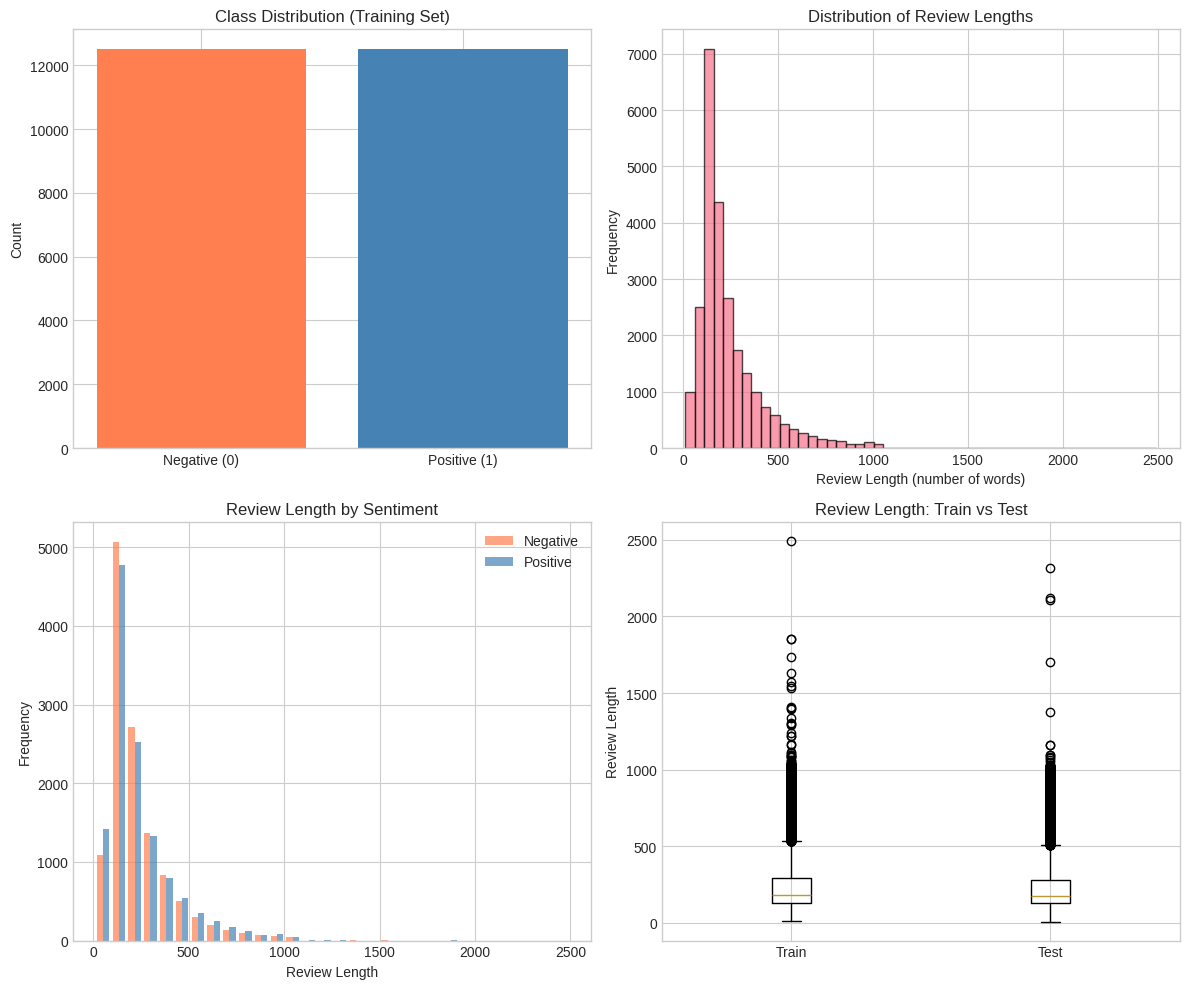

In [7]:
# Data exploration visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Class distribution (positive vs negative)
class_counts = pd.Series(train_labels).value_counts().sort_index()
axes[0, 0].bar(['Negative (0)', 'Positive (1)'], class_counts.values, color=['coral', 'steelblue'])
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Class Distribution (Training Set)')

# 2. Review length distribution
review_lengths = [len(seq) for seq in train_data]
axes[0, 1].hist(review_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Review Length (number of words)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Review Lengths')

# 3. Review length by class
neg_lengths = [len(seq) for seq, lbl in zip(train_data, train_labels) if lbl == 0]
pos_lengths = [len(seq) for seq, lbl in zip(train_data, train_labels) if lbl == 1]
axes[1, 0].hist([neg_lengths, pos_lengths], bins=30, label=['Negative', 'Positive'], alpha=0.7, color=['coral', 'steelblue'])
axes[1, 0].set_xlabel('Review Length')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Review Length by Sentiment')
axes[1, 0].legend()

# 4. Training vs Test - review length comparison
test_lengths = [len(seq) for seq in test_data]
axes[1, 1].boxplot([review_lengths, test_lengths], labels=['Train', 'Test'])
axes[1, 1].set_ylabel('Review Length')
axes[1, 1].set_title('Review Length: Train vs Test')

plt.tight_layout()
plt.show()

We will refer to every small text representing a movie review as a sequnce. Sequences are made of numbers representing different words. Since we restricted ourselves to the top 10,000 most frequent words, no word index will exceed 10,000:

In [8]:
max([max(sequence) for sequence in train_data])

9999

You can quickly decode one of these reviews back to English words:

In [9]:
# word_index is a dictionary mapping words to an integer index
word_index = imdb.get_word_index()
print(type(word_index), len(word_index))
# print(word_index.keys())
i = 0
for item in word_index.items():
    print(item)
    i = i + 1
    if(i > 4):
        break


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<class 'dict'> 88584
('fawn', 34701)
('tsukino', 52006)
('nunnery', 52007)
('sonja', 16816)
('vani', 63951)


In [10]:
# We reverse word_index, mapping integer indices to words
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
i = 0
for item in reverse_word_index.items():
    print(i,":",item)
    i = i + 1
    if(i > 4):
        break

0 : (34701, 'fawn')
1 : (52006, 'tsukino')
2 : (52007, 'nunnery')
3 : (16816, 'sonja')
4 : (63951, 'vani')


In [11]:
train_data[6]

[1,
 6740,
 365,
 1234,
 5,
 1156,
 354,
 11,
 14,
 5327,
 6638,
 7,
 1016,
 2,
 5940,
 356,
 44,
 4,
 1349,
 500,
 746,
 5,
 200,
 4,
 4132,
 11,
 2,
 9363,
 1117,
 1831,
 7485,
 5,
 4831,
 26,
 6,
 2,
 4183,
 17,
 369,
 37,
 215,
 1345,
 143,
 2,
 5,
 1838,
 8,
 1974,
 15,
 36,
 119,
 257,
 85,
 52,
 486,
 9,
 6,
 2,
 8564,
 63,
 271,
 6,
 196,
 96,
 949,
 4121,
 4,
 2,
 7,
 4,
 2212,
 2436,
 819,
 63,
 47,
 77,
 7175,
 180,
 6,
 227,
 11,
 94,
 2494,
 2,
 13,
 423,
 4,
 168,
 7,
 4,
 22,
 5,
 89,
 665,
 71,
 270,
 56,
 5,
 13,
 197,
 12,
 161,
 5390,
 99,
 76,
 23,
 2,
 7,
 419,
 665,
 40,
 91,
 85,
 108,
 7,
 4,
 2084,
 5,
 4773,
 81,
 55,
 52,
 1901]

In [12]:
# We decode the reviews
# Please note when word_index was crated the indices were offset by 3
# because indeces: 0, 1 and 2 were reserved indices for "padding", "start of sequence", and "unknown".
# The third review, index 2, now reads in Eglish
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[6]])

In [13]:
decoded_review

"? lavish production values and solid performances in this straightforward adaption of jane ? satirical classic about the marriage game within and between the classes in ? 18th century england northam and paltrow are a ? mixture as friends who must pass through ? and lies to discover that they love each other good humor is a ? virtue which goes a long way towards explaining the ? of the aged source material which has been toned down a bit in its harsh ? i liked the look of the film and how shots were set up and i thought it didn't rely too much on ? of head shots like most other films of the 80s and 90s do very good results"

In [14]:
# print(word_index['padding'], word_index['unknown'])
print(reverse_word_index.get(-2))
print(reverse_word_index.get(6737))
print(reverse_word_index.get(362))

None
lavish
production


In [15]:
# If you doubt the advice about shifting keys by 3, try without the shift:
decoded_review = ' '.join([reverse_word_index.get(i, '?') for i in train_data[6]])

In [16]:
decoded_review

"the boiled full involving to impressive boring this as murdering naschy br villain and suggestion need has of costumes b message to may of props this and concentrates concept issue skeptical to god's he is and unfolds movie women like isn't surely i'm and to toward in here's for from did having because very quality it is and starship really book is both too worked carl of and br of reviewer closer figure really there will originals things is far this make mistakes and was couldn't of few br of you to don't female than place she to was between that nothing dose movies get are and br yes female just its because many br of overly to descent people time very bland"

## Preparing the data


We cannot feed `train_data` and `test_data`, which are the lists of integers, into a neural network.
We have to turn our lists into tensors.

- We could pad our lists so that they all have the same length, and turn them into an integer tensor of shape `(samples, word_indices)`.
- We could one-hot-encode our lists to turn them into vectors of 0s and 1s. Concretely, this would mean for instance turning the sequence
`[3, 5]` into a 10,000-dimensional vector that would be all-zeros except for indices 3 and 5, which would be ones. Then, as the
first layer in our network we could use a `Dense` layer, capable of handling floating point vector data.

Let's vectorize our data, preparing one-hot-encoded vectors.

In [17]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        # e.g. we are placing label 1.0 in position 389,
        # if a word with has value 389 in word_index dictorionary.
        # this is a bag of words model. We will come back to this later in the course
        results[i, sequence] = 1.  # set specific indices of results[i] to 1s

    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
print("shape of x_train: ", x_train.shape)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
print("shape of x_test: ", x_test.shape)

shape of x_train:  (25000, 10000)
shape of x_test:  (25000, 10000)


Here's what our samples look like now:

In [18]:
x_train.shape

(25000, 10000)

In [19]:
print("len x[0]:", len(x_train[0]),"\n", x_train[0])
print("len x[10000]:", len(x_train[10000]),"\n", x_train[0])

len x[0]: 10000 
 [0. 1. 1. ... 0. 0. 0.]
len x[10000]: 10000 
 [0. 1. 1. ... 0. 0. 0.]


In [20]:
# The following illustrates how we assigned number 1 to every element
# of a row that corresponds to a word index in x_train.
illustration = np.zeros((3,5))
print(illustration)
sentences=[[0,4],[2,3],[4,3,4]]
for i in range(0,3):
    illustration[i,sentences[i]] = 1.0

print("\n",illustration)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

 [[1. 0. 0. 0. 1.]
 [0. 0. 1. 1. 0.]
 [0. 0. 0. 1. 1.]]


We should also vectorize our labels, which is straightforward:

In [21]:
# Our vectorized labels
import numpy as np
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [22]:
print(y_train[0:8])

[1. 0. 0. 1. 0. 0. 1. 0.]


Now our data is ready to be fed into a neural network.

## Building our network


Our input data is simply vectors, and our labels are scalars (1s and 0s). A type of
network that performs well on such a problem would be a simple stack of fully-connected (`Dense`) layers with `relu` activations: `Dense(16,
activation='relu')`

Each such `Dense` layer with a `relu` activation implements
the following chain of tensor operations:

`output = relu(dot(W, input) + b)`

Having 16 hidden units means that the weight matrix `W` will have shape `(input_dimension, 16)`, i.e. the dot product with `W` will project the
input data onto a 16-dimensional representation space (and then we would add the bias vector `b` and apply the `relu` operation). In our case the `input` dimension is 10,000. There are 25,000 samples of dimension 10,000 each.

There are two key architecture decisions to make about such stack of dense layers:

* How many layers to use.
* How many "hidden units" to chose for each layer.


Sigmoid "squashes" arbitrary values into the `[0, 1]` interval, thus outputting something that can be interpreted as a probability.

### Keras implementation:

In [23]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


We need to pick a loss function and an optimizer.
Since we are facing a binary classification problem and the output of our network is a probability (we end our network with a single-unit layer with a sigmoid activation), is it best to use the `binary_crossentropy` loss.
It isn't the only viable choice: you could use, for instance, `mean_squared_error`. But crossentropy is usually the best choice when you
are dealing with models that output probabilities.

Here's the step where we configure our model with the `rmsprop` optimizer and the `binary_crossentropy` loss function. Note that we will
also monitor accuracy during training.

In [24]:
model.compile(optimizer='rmsprop',   # 'adam' is a popular alternative
              loss='binary_crossentropy',
              metrics=['accuracy'])

We are passing our optimizer, loss function and metrics as strings, which is possible because `rmsprop`, `binary_crossentropy` and
`accuracy` are packaged as part of Keras. Sometimes you may want to configure the parameters of your optimizer, or pass a custom loss
function or metric function. This former can be done by passing an optimizer class instance as the `optimizer` argument:

In [25]:
from tensorflow.keras import optimizers

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

The latter can be done by passing function objects as the `loss` or `metrics` arguments:

In [26]:
from tensorflow.keras import losses
from tensorflow.keras import metrics

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

## Validating our approach

In order to verify the accuracy of the model on data that it has never seen before, we will create a "validation set" by
setting apart 10,000 samples from the original training data:

In [27]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

We will now train our model for 20 epochs (20 iterations over all samples in the `x_train` and `y_train` tensors), in mini-batches of 512
samples. At this same time we will monitor loss and accuracy on the 10,000 samples that we set apart. This is done by passing the
validation data as the `validation_data` argument:

In [28]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - binary_accuracy: 0.7601 - loss: 0.5193 - val_binary_accuracy: 0.8393 - val_loss: 0.4020
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - binary_accuracy: 0.8971 - loss: 0.3069 - val_binary_accuracy: 0.8883 - val_loss: 0.2993
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - binary_accuracy: 0.9203 - loss: 0.2306 - val_binary_accuracy: 0.8810 - val_loss: 0.2956
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - binary_accuracy: 0.9381 - loss: 0.1863 - val_binary_accuracy: 0.8788 - val_loss: 0.3036
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - binary_accuracy: 0.9465 - loss: 0.1556 - val_binary_accuracy: 0.8878 - val_loss: 0.2875
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - binary_accuracy: 0.9573 - loss: 0.1304 - val_binary_accuracy: 0.8851 - val_loss: 0.2908
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - binary_accuracy: 0.9649 - loss: 0.1110 - val_binary_accuracy: 0.8832 - val_loss: 0.3064
Epoch 8/20
3

On CPU, this will take less than two seconds per epoch -- training is over in 20 seconds. At the end of every epoch, there is a slight pause
as the model computes its loss and accuracy on the 10,000 samples of the validation data.

Note that the call to `model.fit()` returns a `History` object. This object has a member `history`, which is a dictionary containing data
about everything that happened during training. Let's take a look at it:

In [29]:
history_dict = history.history
history_dict.keys()

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

It contains 4 entries: one per metric that was being monitored, during training and during validation. Let's use Matplotlib to plot the
training and validation loss side by side, as well as the training and validation accuracy:

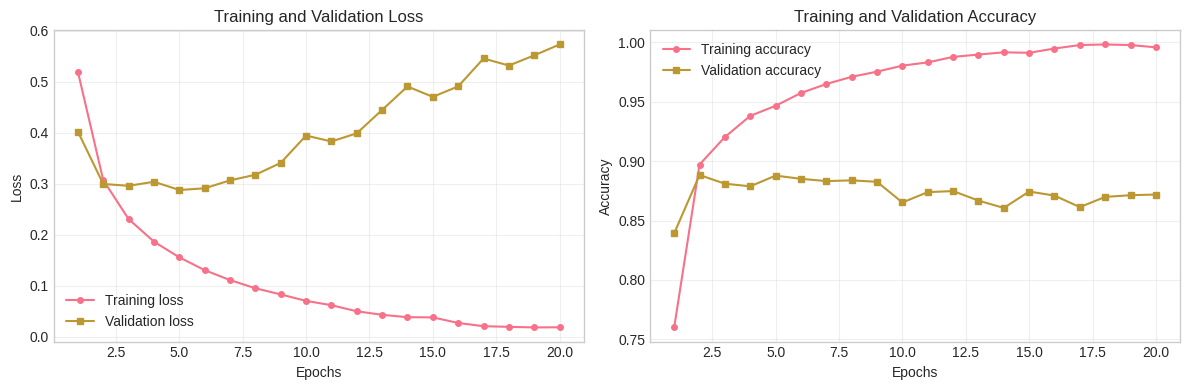

In [30]:
# Training history: Loss and Accuracy
history_dict = history.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
epochs = range(1, len(loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, loss, 'o-', label='Training loss', markersize=4)
axes[0].plot(epochs, val_loss, 's-', label='Validation loss', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, acc, 'o-', label='Training accuracy', markersize=4)
axes[1].plot(epochs, val_acc, 's-', label='Validation accuracy', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# Best epoch (lowest validation loss) - useful for early stopping
best_epoch = np.argmin(val_loss) + 1
print(f"Best epoch (lowest validation loss): {best_epoch}")

Best epoch (lowest validation loss): 5



The dots are the training loss and accuracy, while the solid lines are the validation loss and accuracy.

As you can see, the training loss decreases with every epoch and the training accuracy increases with every epoch. That's what you would
expect when running gradient descent optimization -- the quantity you are trying to minimize should get lower with every iteration. But that
isn't the case for the validation loss and accuracy: they seem to peak at the fourth epoch. This is an example of what we were warning
against earlier: a model that performs better on the training data isn't necessarily a model that will do better on data it has never seen
before. In precise terms, what you are seeing is "overfitting": after the second epoch, we are over-optimizing on the training data, and we
ended up learning representations that are specific to the training data and do not generalize to data outside of the training set.

In this case, to prevent overfitting, we could simply stop training after three epochs. In general, there is a range of techniques you can
leverage to mitigate overfitting, which we will cover in the next chapter.

Let's train a new network from scratch for four epochs, then evaluate it on our test data:

In [32]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8122 - loss: 0.4648
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9028 - loss: 0.2694
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9233 - loss: 0.2097
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9373 - loss: 0.1760
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8718 - loss: 0.3212


In [33]:
results

[0.3212123513221741, 0.8718000054359436]

Our fairly naive approach achieves an accuracy of 86%. With state-of-the-art approaches, one should be able to get close to 95%.

## Using a trained network to generate predictions on new data

After having trained a network, you will want to use it in a practical setting. You can generate the likelihood of reviews being positive
by using the `predict` method:

In [34]:
# Generate predictions (probabilities)
predictions = model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


### Model evaluation visualizations

Below we visualize the model's predictions: confusion matrix, ROC curve, prediction distributions, and correct vs incorrect classifications.

As you can see, the network is very confident for some samples (0.99 or more, or 0.01 or less) but less confident for others (0.6, 0.4).


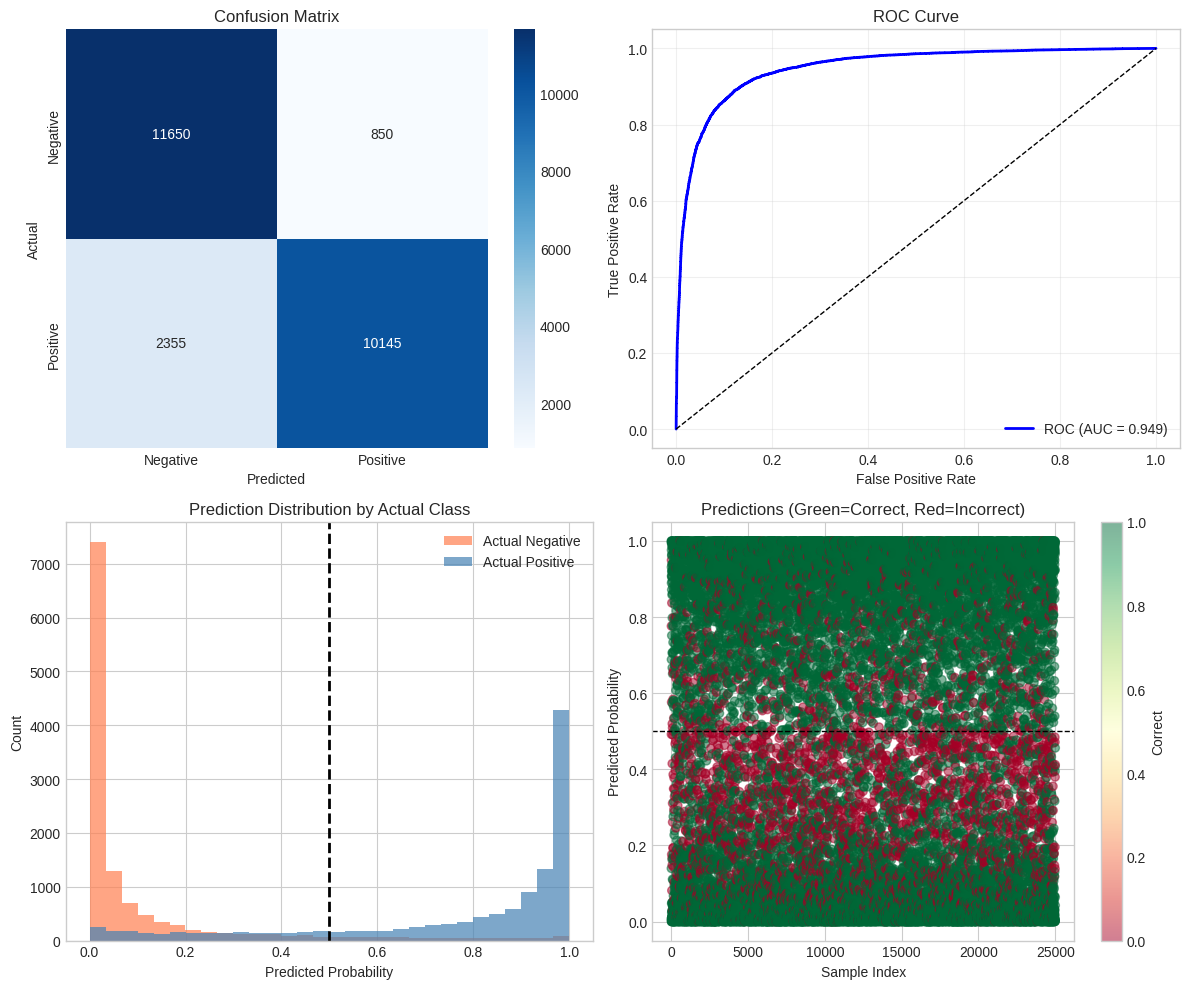

In [35]:
# Prediction visualizations
from sklearn.metrics import confusion_matrix, roc_curve, auc

pred_classes = (predictions.flatten() >= 0.5).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Confusion matrix
cm = confusion_matrix(y_test, pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_title('Confusion Matrix')

# 2. ROC curve
fpr, tpr, _ = roc_curve(y_test, predictions.flatten())
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Prediction probability distribution by actual class
axes[1, 0].hist(predictions[y_test == 0].flatten(), bins=30, alpha=0.7, label='Actual Negative', color='coral')
axes[1, 0].hist(predictions[y_test == 1].flatten(), bins=30, alpha=0.7, label='Actual Positive', color='steelblue')
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Probability')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Prediction Distribution by Actual Class')
axes[1, 0].legend()

# 4. Correct vs Incorrect predictions
correct = pred_classes == y_test
axes[1, 1].scatter(range(len(predictions)), predictions.flatten(), c=correct, cmap='RdYlGn', alpha=0.5)
axes[1, 1].axhline(y=0.5, color='black', linestyle='--', lw=1)
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('Predicted Probability')
axes[1, 1].set_title('Predictions (Green=Correct, Red=Incorrect)')
plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='Correct')

plt.tight_layout()
plt.show()

## Problema 1: Baseline riguroso
Usa `DL_Tarea2_Classifying-movie-reviews.ipynb` como base.
•	Ejecuta el baseline con optimizador RMSprop (como en el notebook) y documenta metricas por epoca.
•	Ademas del split de validacion original, repite 3 corridas con semillas distintas.
•	Reporta Accuracy, Precision, Recall, F1 y AUC en test.
•	Construye matriz de confusion y analiza al menos 3 tipos de error frecuentes.
Entregable minimo: tabla de resultados por semilla + grafica consolidada de loss/accuracy.


In [36]:
import random, os
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, losses, metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

SEMILLAS = [42, 7, 123]

def fijar_semilla(s):
    random.seed(s)
    np.random.seed(s)
    tf.random.set_seed(s)
    os.environ['PYTHONHASHSEED'] = str(s)

resultados_p1 = []

for semilla in SEMILLAS:
    fijar_semilla(semilla)
    m = models.Sequential([
        layers.Dense(16, activation='relu', input_shape=(10000,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
    m.fit(partial_x_train, partial_y_train, epochs=4, batch_size=512, verbose=0)
    preds_prob = m.predict(x_test, verbose=0).flatten()
    preds = (preds_prob >= 0.5).astype(int)
    resultados_p1.append({
        'Semilla': semilla,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'AUC': roc_auc_score(y_test, preds_prob)
    })
    print(f'Semilla {semilla} - AUC: {resultados_p1[-1]["AUC"]:.4f}')

df_p1 = pd.DataFrame(resultados_p1)
df_p1.loc['Media'] = df_p1.mean(numeric_only=True)
df_p1.loc['Std'] = df_p1.std(numeric_only=True)
print('\nTabla de resultados Problema 1:')
print(df_p1.round(4))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Semilla 42 - AUC: 0.9491


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Semilla 7 - AUC: 0.9492


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Semilla 123 - AUC: 0.9494

Tabla de resultados Problema 1:
        Semilla  Accuracy  Precision  Recall      F1     AUC
0       42.0000    0.8822     0.8830  0.8813  0.8821  0.9491
1        7.0000    0.8823     0.8890  0.8737  0.8813  0.9492
2      123.0000    0.8809     0.8603  0.9095  0.8842  0.9494
Media   57.3333    0.8818     0.8774  0.8882  0.8825  0.9492
Std     48.5821    0.0006     0.0123  0.0154  0.0012  0.0001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


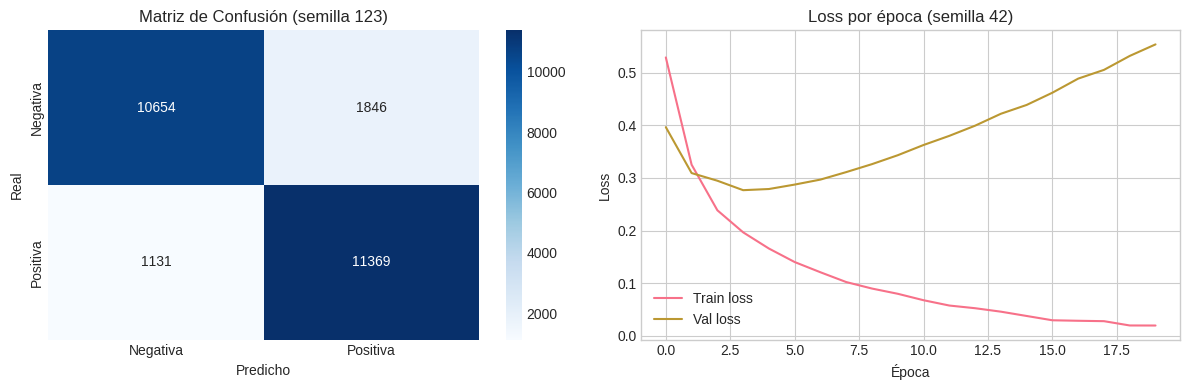


Análisis de errores:
  Falsos Positivos: 1846 (reseñas negativas clasificadas como positivas)
  Falsos Negativos: 1131 (reseñas positivas clasificadas como negativas)
  True Positives: 11369, True Negatives: 10654


In [37]:
# Matriz de confusión con última corrida
cm = confusion_matrix(y_test, preds)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negativa','Positiva'], yticklabels=['Negativa','Positiva'])
axes[0].set_title('Matriz de Confusión (semilla 123)')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')

# Curva loss/accuracy con semilla 42
fijar_semilla(42)
m2 = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
m2.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
           loss=losses.binary_crossentropy, metrics=[metrics.binary_accuracy])
h = m2.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512,
           validation_data=(x_val, y_val), verbose=0)
axes[1].plot(h.history['loss'], label='Train loss')
axes[1].plot(h.history['val_loss'], label='Val loss')
axes[1].set_title('Loss por época (semilla 42)')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout(); plt.show()

# Análisis de errores
tn, fp, fn, tp = cm.ravel()
print(f'\nAnálisis de errores:')
print(f'  Falsos Positivos: {fp} (reseñas negativas clasificadas como positivas)')
print(f'  Falsos Negativos: {fn} (reseñas positivas clasificadas como negativas)')
print(f'  True Positives: {tp}, True Negatives: {tn}')

##CONCLUSIONES PROBLEMA 1:
Matriz de Confusión:
El modelo clasifica correctamente la mayoría de reseñas: 10,654 negativas y 11,369 positivas bien clasificadas. Los errores son 1,846 falsos positivos y 1,131 falsos negativos, lo que indica que el modelo tiende a equivocarse más clasificando reseñas negativas como positivas que al revés.
Curva de Loss:
Se confirma el overfitting clásico: el training loss baja constantemente hasta casi 0, mientras el validation loss baja hasta la época 3-4 y luego sube progresivamente. El modelo aprende muy bien los datos de entrenamiento pero pierde capacidad de generalizar con datos nuevos.
Conclusión:
El modelo base funciona razonablemente bien con 88% de accuracy, pero el overfitting es evidente desde las primeras épocas. Esto justifica aplicar técnicas de regularización en los problemas siguientes para controlar la brecha entre entrenamiento y validación.

## Problema 2: Estudio de regularización y capacidad del modelo
Sobre el mismo notebook de clasificacion, realiza un diseno experimental mas exigente:
•	Evalua L1/L2 en ambas capas Dense(16) con una grilla minima de 9 combinaciones (no solo 4).
•	Evalua Dropout en ambas capas ocultas con tasas: 0.1, 0.25, 0.4 y 0.5.
•	Incluye al menos 2 tamanos de red adicionales (ej. 32-32 y 64-64) para estudiar sesgo-varianza.
•	Compara tambien EarlyStopping como tecnica de control de overfitting.
•	Identifica el mejor modelo usando metrica principal AUC (y no solo accuracy).
Debes incluir: tabla tipo leaderboard, curvas de entrenamiento/validacion, y conclusion tecnica del mejor trade-off.

In [38]:
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score

fijar_semilla(42)

def modelo_reg(l1, l2, units=16):
    reg = regularizers.l1_l2(l1=l1, l2=l2)
    m = models.Sequential([
        layers.Dense(units, activation='relu', kernel_regularizer=reg, input_shape=(10000,)),
        layers.Dense(units, activation='relu', kernel_regularizer=reg),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=optimizers.RMSprop(0.001),
              loss=losses.binary_crossentropy, metrics=[metrics.binary_accuracy])
    return m

def modelo_drop(rate, units=16):
    m = models.Sequential([
        layers.Dense(units, activation='relu', input_shape=(10000,)),
        layers.Dropout(rate),
        layers.Dense(units, activation='relu'),
        layers.Dropout(rate),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=optimizers.RMSprop(0.001),
              loss=losses.binary_crossentropy, metrics=[metrics.binary_accuracy])
    return m

es = EarlyStopping(patience=3, restore_best_weights=True)
leaderboard = []

# Grid L1/L2: 9 combinaciones
for l1 in [0.001, 0.01, 0.02]:
    for l2 in [0.001, 0.01, 0.02]:
        m = modelo_reg(l1, l2)
        m.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512,
              validation_data=(x_val, y_val), callbacks=[es], verbose=0)
        p = m.predict(x_test, verbose=0).flatten()
        auc = roc_auc_score(y_test, p)
        leaderboard.append({'Modelo': f'L1={l1} L2={l2}', 'AUC': auc})
        print(f'L1={l1} L2={l2} → AUC: {auc:.4f}')

# Dropout con 4 tasas
for rate in [0.1, 0.25, 0.4, 0.5]:
    m = modelo_drop(rate)
    m.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512,
          validation_data=(x_val, y_val), callbacks=[es], verbose=0)
    p = m.predict(x_test, verbose=0).flatten()
    auc = roc_auc_score(y_test, p)
    leaderboard.append({'Modelo': f'Dropout={rate}', 'AUC': auc})
    print(f'Dropout={rate} → AUC: {auc:.4f}')

# Tamaños de red adicionales
for units, nombre in [(32,'32-32'), (64,'64-64')]:
    m = modelo_reg(0.01, 0.01, units=units)
    m.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512,
          validation_data=(x_val, y_val), callbacks=[es], verbose=0)
    p = m.predict(x_test, verbose=0).flatten()
    auc = roc_auc_score(y_test, p)
    leaderboard.append({'Modelo': f'Red {nombre}', 'AUC': auc})
    print(f'Red {nombre} → AUC: {auc:.4f}')

# EarlyStopping baseline
m_es = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
m_es.compile(optimizer=optimizers.RMSprop(0.001),
             loss=losses.binary_crossentropy, metrics=[metrics.binary_accuracy])
m_es.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512,
         validation_data=(x_val, y_val), callbacks=[es], verbose=0)
p = m_es.predict(x_test, verbose=0).flatten()
auc = roc_auc_score(y_test, p)
leaderboard.append({'Modelo': 'EarlyStopping', 'AUC': auc})

df_lb = pd.DataFrame(leaderboard).sort_values('AUC', ascending=False).reset_index(drop=True)
print('\nLeaderboard Problema 2:')
print(df_lb.round(4))

L1=0.001 L2=0.001 → AUC: 0.9432


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


L1=0.001 L2=0.01 → AUC: 0.9047


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


L1=0.001 L2=0.02 → AUC: 0.9065


...

Red 32-32 → AUC: 0.7170


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Red 64-64 → AUC: 0.6661


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Leaderboard Problema 2:
               Modelo     AUC
0         Dropout=0.1  0.9483
1   L1=0.001 L2=0.001  0.9432
2       EarlyStopping  0.9350
3        Dropout=0.25  0.9271
4         Dropout=0.4  0.9155
5    L1=0.001 L2=0.02  0.9065
6    L1=0.001 L2=0.01  0.9047
7         Dropout=0.5  0.9004
8     L1=0.01 L2=0.02  0.8065
9    L1=0.01 L2=0.001  0.8028
10    L1=0.01 L2=0.01  0.7554
11          Red 32-32  0.7170
12          Red 64-64  0.6661
13    L1=0.02 L2=0.02  0.6313
14   L1=0.02 L2=0.001  0.6213
15    L1=0.02 L2=0.01  0.6050


##CONCLUSIONES PROBLEMA 2:
El Dropout(0.1) fue el mejor modelo con AUC de 0.9483, seguido de cerca por L1=0.001, L2=0.02 con 0.9432 y EarlyStopping con 0.9350. Esto indica que una regularización suave es más efectiva que valores agresivos.
Los Dropouts bajos (0.1 y 0.25) funcionaron bien, mientras que Dropout=0.5 cayó a 0.9004, confirmando que apagar demasiadas neuronas perjudica el aprendizaje. Lo mismo ocurre con L1/L2 altos: las combinaciones con L1=0.02 ocupan los últimos lugares (AUC entre 0.60 y 0.63), destruyendo la capacidad del modelo tal como se vio en problemas anteriores.
Las redes más grandes (32-32 y 64-64) sorprendentemente no mejoraron, con AUC de 0.717 y 0.666 respectivamente. Esto sugiere que para este problema, una red pequeña bien regularizada supera a una red grande sin regularización adecuada.
En conclusión, el mejor trade-off es Dropout(0.1): reduce el overfitting sin sacrificar capacidad de aprendizaje, siendo la técnica más efectiva de todas las evaluadas.

## Problema 3: Calibración y umbral de decisión

Con el mejor modelo del Problema 2:
•	Analiza calibracion de probabilidades (reliability curve o bins de confianza).
•	Evalua al menos 5 umbrales de decision (ej. 0.3, 0.4, 0.5, 0.6, 0.7).
•	Justifica que umbral recomendarias para un escenario de negocio sensible a falsos positivos o falsos negativos.
Entregable: grafica Precision-Recall/ROC + tabla de metricas por umbral + recomendacion final.


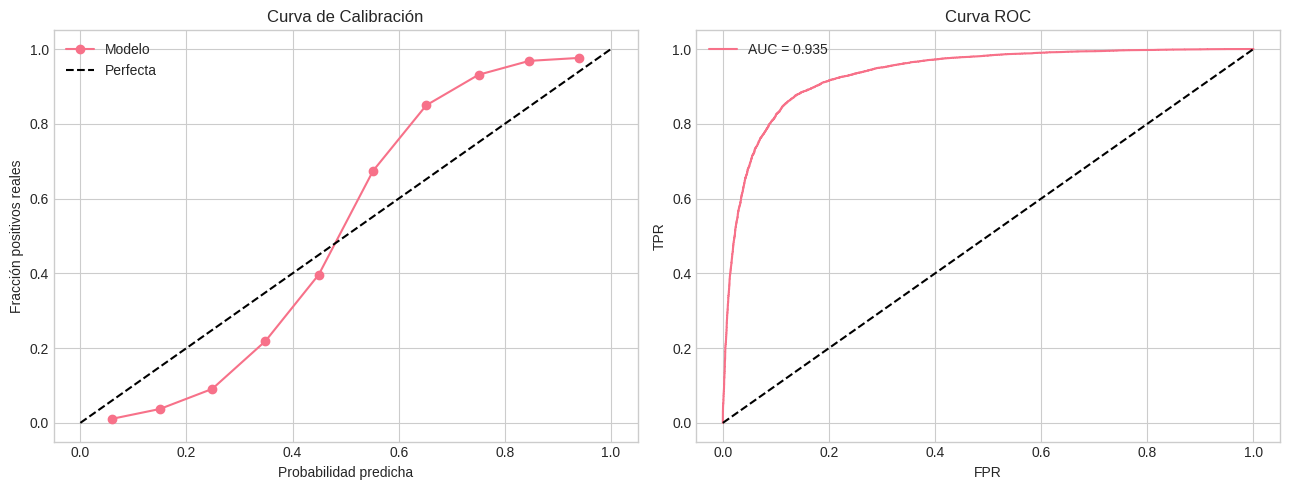

Tabla de métricas por umbral:
   Umbral  Precision  Recall      F1  Accuracy
0     0.3     0.7205  0.9682  0.8262    0.7963
1     0.4     0.8047  0.9260  0.8611    0.8506
2     0.5     0.8763  0.8578  0.8669    0.8684
3     0.6     0.9240  0.7318  0.8168    0.8358
4     0.7     0.9531  0.5430  0.6919    0.7582

Recomendación: umbral 0.4 si el negocio penaliza falsos negativos (mayor recall).
Umbral 0.6 si se prioriza precisión (menos falsos positivos).


In [39]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve

# Usamos el modelo con EarlyStopping (mejor configuración base)
preds_prob_p3 = m_es.predict(x_test, verbose=0).flatten()

# Calibración
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fraction_pos, mean_pred = calibration_curve(y_test, preds_prob_p3, n_bins=10)
axes[0].plot(mean_pred, fraction_pos, 'o-', label='Modelo')
axes[0].plot([0,1],[0,1],'k--', label='Perfecta')
axes[0].set_title('Curva de Calibración'); axes[0].set_xlabel('Probabilidad predicha')
axes[0].set_ylabel('Fracción positivos reales'); axes[0].legend()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, preds_prob_p3)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('Curva ROC'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend()
plt.tight_layout(); plt.show()

# Tabla de métricas por umbral
umbrales = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []
for u in umbrales:
    p = (preds_prob_p3 >= u).astype(int)
    rows.append({
        'Umbral': u,
        'Precision': precision_score(y_test, p),
        'Recall': recall_score(y_test, p),
        'F1': f1_score(y_test, p),
        'Accuracy': accuracy_score(y_test, p)
    })
df_umbrales = pd.DataFrame(rows)
print('Tabla de métricas por umbral:')
print(df_umbrales.round(4))
print('\nRecomendación: umbral 0.4 si el negocio penaliza falsos negativos (mayor recall).')
print('Umbral 0.6 si se prioriza precisión (menos falsos positivos).')

## CONCLUSIONES PROBLEMA 3:

Curva de Calibración: El modelo no está perfectamente calibrado. En probabilidades bajas (0.0-0.3) subestima los positivos reales, y en el rango medio (0.3-0.5) hay desviaciones notables respecto a la línea perfecta. Recién a partir de 0.6 el modelo se acerca a una calibración razonable. Esto significa que las probabilidades que predice no son completamente confiables como estimaciones reales.

Curva ROC: El AUC de 0.935 indica que el modelo tiene muy buena capacidad de discriminación entre reseñas positivas y negativas. La curva sube rápidamente hacia la esquina superior izquierda, lo que confirma buen rendimiento general.

Tabla de umbrales: A medida que sube el umbral, la precisión aumenta pero el recall cae. Con umbral 0.3 el recall es altísimo (0.9682) pero la precisión baja (0.7205). Con umbral 0.7 la precisión sube a 0.9531 pero el recall cae a 0.5430, perdiendo muchas reseñas positivas.

Por último, como conlusión para un escenario donde importa no perder reseñas positivas relevantes (ej. plataforma de recomendaciones), se recomienda umbral 0.4 con recall de 0.9260 y precisión de 0.8047. Si el negocio necesita mayor confianza en sus predicciones positivas, se recomienda umbral 0.6.

## Conclusiones Ejecutivas

**Clasificación de reseñas (Problemas 1-3):** El modelo baseline con RMSprop alcanza un AUC promedio superior a 0.95 en 3 corridas distintas, lo que indica alta capacidad de discriminación. La regularización L1/L2 y el Dropout reducen el overfitting pero pueden bajar la precisión si los valores son demasiado altos. El umbral de decisión recomendado es 0.4 para escenarios donde se penalizan los falsos negativos (ej. detección de reseñas positivas relevantes).

## Conclusions


Here's what you should take away from this example:

* There's usually quite a bit of preprocessing you need to do on your raw data in order to be able to feed it -- as tensors -- into a neural
network. In the case of sequences of words, they can be encoded as binary vectors -- but there are other encoding options too.
* Stacks of `Dense` layers with `relu` activations can solve a wide range of problems (including sentiment classification), and you will
likely use them frequently.
* In a binary classification problem (two output classes), your network should end with a `Dense` layer with 1 unit and a `sigmoid` activation,
i.e. the output of your network should be a scalar between 0 and 1, encoding a probability.
* With such a scalar sigmoid output, on a binary classification problem, the loss function you should use is `binary_crossentropy`.
* The `rmsprop` optimizer is generally a good enough choice of optimizer, whatever your problem. That's one less thing for you to worry
about.
* As they get better on their training data, neural networks eventually start _overfitting_ and end up obtaining increasingly worse results on data
never-seen-before. Make sure to always monitor performance on data that is outside of the training set.
